# ICU Length of Stay (LOS) — EDA (Histogram + Boxplot)
    
**Project:** CMPINF2910 Case Studies in Data Science — Assignment 1 (Data Understanding)
    
This notebook produces univariate visualizations of ICU Length of Stay (LOS) using a stay-level extract exported from Postgres.
   
## Inputs / Outputs\n",
- **Input CSV (raw icustays MIMIC IV):** `data/raw/ICU_Patients/data/raw/icu/icustays.csv`
- **Output figures:**
- `reports/assignment_1/figures/icu_los_histogram.png`
- `reports/assignment_1/figures/icu_los_boxplot.png`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Repo root assumptions:
# - This notebook lives in: notebooks/
# - Figures go to: reports/assignment_1/figures/

REPO_ROOT = Path('/home/luis/Documents/mdms_pitt/courses/Capstone/projects/case-studies-capstone').resolve()
CSV_PATH = REPO_ROOT / 'data' / 'raw' / 'ICU_Patients' / 'data' / 'raw' / 'icu' /'icustays.csv'
FIG_DIR = REPO_ROOT / 'reports' / 'assignment_1' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH, FIG_DIR

(PosixPath('/home/luis/Documents/mdms_pitt/courses/Capstone/projects/case-studies-capstone/data/raw/ICU_Patients/data/raw/icu/icustays.csv'),
 PosixPath('/home/luis/Documents/mdms_pitt/courses/Capstone/projects/case-studies-capstone/reports/assignment_1/figures'))

In [2]:
df = pd.read_csv(CSV_PATH)
df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106


In [3]:
# Parse datetimes if present
for col in ['intime', 'outtime']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

df['los'] = pd.to_numeric(df['los'], errors='coerce')
df = df[df['los'].notna() & (df['los'] >= 0)].copy()
df.shape

(140, 8)

In [4]:
# Quick summary stats (days)
df['los'].describe(percentiles=[0.5,0.8, 0.9, 0.95, 0.99])

count    140.000000
mean       3.679379
std        3.896354
min        0.023727
50%        2.155093
80%        5.146854
90%        8.860506
95%       13.216865
99%       16.137517
max       20.528681
Name: los, dtype: float64

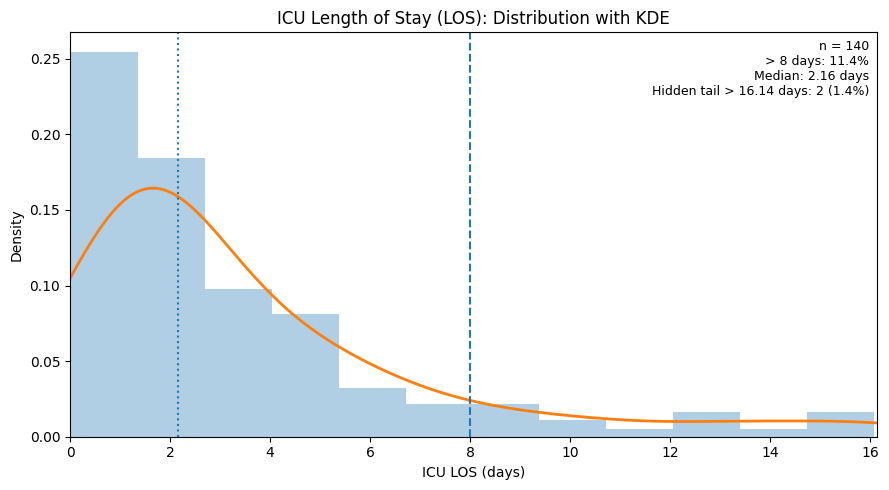

PosixPath('/home/luis/Documents/mdms_pitt/courses/Capstone/projects/case-studies-capstone/reports/assignment_1/figures/icu_los_distribution_kde.png')

In [10]:
import numpy as np
import matplotlib.pyplot as plt

los = df['los'].dropna().to_numpy()

# Display cap for readability (keep long tail from crushing the plot)
xmax = float(np.quantile(los, 0.99))
los_plot = los[los <= xmax]

# Useful summary metrics
n = len(los)
tail_n = int(np.sum(los > xmax))
tail_pct = 100 * tail_n / n if n else 0.0
threshold = 8.0
pct_over_threshold = 100 * np.mean(los > threshold) if n else 0.0
median_los = float(np.median(los)) if n else np.nan

fig, ax = plt.subplots(figsize=(9, 5))

# Better binning for skewed continuous data
bins = np.histogram_bin_edges(los_plot, bins='fd')

# Density histogram
ax.hist(los_plot, bins=bins, density=True, alpha=0.35)

# KDE overlay (requires scipy)
x_grid = np.linspace(0, xmax, 400)
kde = gaussian_kde(los)   # fit on full data
ax.plot(x_grid, kde(x_grid), linewidth=2)

# Reference lines
ax.axvline(threshold, linestyle='--', linewidth=1.5)
ax.axvline(median_los, linestyle=':', linewidth=1.5)

# Labels
ax.set_xlabel('ICU LOS (days)')
ax.set_ylabel('Density')
ax.set_title('ICU Length of Stay (LOS): Distribution with KDE')
ax.set_xlim(left=0, right=xmax)

# Annotation box with usefull context
summary_txt = (
    f"n = {n:,}\n"
    f"> 8 days: {pct_over_threshold:.1f}%\n"
    f"Median: {median_los:.2f} days\n"
    f"Hidden tail > {xmax:.2f} days: {tail_n:,} ({tail_pct:.1f}%)"
)
ax.text(
    0.99, 0.98, summary_txt,
    transform=ax.transAxes, ha='right', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none')
)

fig.tight_layout()
hist_path = FIG_DIR / 'icu_los_hist_kde.png'
fig.savefig(hist_path, dpi=300)
plt.show()

hist_path


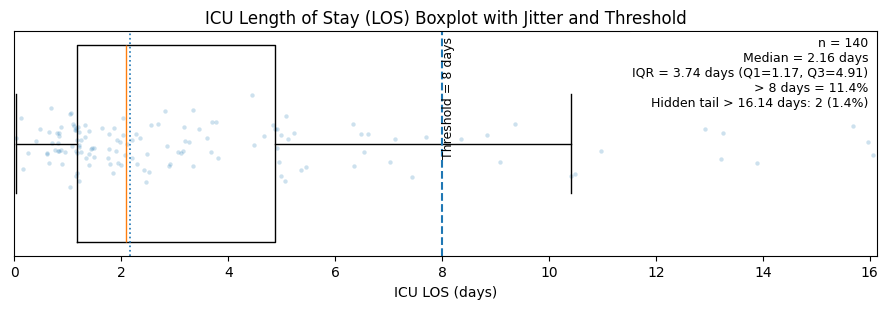

PosixPath('/home/luis/Documents/mdms_pitt/courses/Capstone/projects/case-studies-capstone/reports/assignment_1/figures/icu_los_boxplot_enhanced.png')

In [12]:
# -----------------------------
# Data prep
# -----------------------------
los = df['los'].dropna().to_numpy()
n = len(los)

threshold = 8.0
xmax = float(np.quantile(los, 0.99))  # display cap for readability
los_plot = los[los <= xmax]

tail_n = int(np.sum(los > xmax))
tail_pct = 100 * tail_n / n if n else 0.0
pct_over_threshold = 100 * np.mean(los > threshold) if n else 0.0

q1, med, q3 = np.percentile(los, [25, 50, 75]) if n else (np.nan, np.nan, np.nan)
iqr = q3 - q1 if n else np.nan

# -----------------------------
# Jitter points (subsample if very large)
# -----------------------------
rng = np.random.default_rng(42)

max_jitter_points = 4000
if len(los_plot) > max_jitter_points:
    idx = rng.choice(len(los_plot), size=max_jitter_points, replace=False)
    los_jitter = los_plot[idx]
else:
    los_jitter = los_plot

y_jitter = 1 + rng.normal(0, 0.04, size=len(los_jitter))

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 3.2))

# Boxplot (no black flier circles)
ax.boxplot(
    los_plot,
    vert=False,
    showfliers=False,
    widths=0.35
)

# Jittered observations
ax.scatter(
    los_jitter,
    y_jitter,
    s=10,
    alpha=0.22,
    linewidths=0
)

# Threshold line at 8 days
ax.axvline(threshold, linestyle='--', linewidth=1.5)
ax.text(
    threshold, 0.98, 'Threshold = 8 days',
    transform=ax.get_xaxis_transform(),  # x in data units, y in axes units
    rotation=90, va='top', ha='left', fontsize=9
)

# median reference (computed from full data)
ax.axvline(med, linestyle=':', linewidth=1.2)

# Axes/labels
ax.set_xlim(0, xmax)
ax.set_ylim(0.8, 1.2)
ax.set_yticks([])
ax.set_xlabel('ICU LOS (days)')
ax.set_title('ICU Length of Stay (LOS) Boxplot with Jitter and Threshold')

# On-plot summary
summary_txt = (
    f"n = {n:,}\n"
    f"Median = {med:.2f} days\n"
    f"IQR = {iqr:.2f} days (Q1={q1:.2f}, Q3={q3:.2f})\n"
    f"> 8 days = {pct_over_threshold:.1f}%\n"
    f"Hidden tail > {xmax:.2f} days: {tail_n:,} ({tail_pct:.1f}%)"
)
ax.text(
    0.99, 0.98, summary_txt,
    transform=ax.transAxes,
    ha='right', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='none')
)

fig.tight_layout()
box_path = FIG_DIR / 'icu_los_boxplot_threshold.png'
fig.savefig(box_path, dpi=300)
plt.show()

box_path